In [1]:
# STEP 4.1 – Import Libraries

import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score
)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Model saving
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [2]:
# STEP 4.2 – Load Model-Ready Data

X_cls = pd.read_csv('../data/X_classification.csv')
y_cls = pd.read_csv('../data/y_classification.csv')

X_reg = pd.read_csv('../data/X_regression.csv')
y_reg = pd.read_csv('../data/y_regression.csv')

X_cluster = pd.read_csv('../data/X_clustering.csv')

print("Classification:", X_cls.shape, y_cls.shape)
print("Regression    :", X_reg.shape, y_reg.shape)
print("Clustering    :", X_cluster.shape)


Classification: (132379, 18) (132379, 1)
Regression    : (132379, 18) (132379, 1)
Clustering    : (132379, 18)


In [3]:
# STEP 4.3 – Train-Test Split
# Classification Split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Classification Train:", X_train_cls.shape)
print("Classification Test :", X_test_cls.shape)


Classification Train: (105903, 18)
Classification Test : (26476, 18)


In [4]:
# Regression Split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression Train:", X_train_reg.shape)
print("Regression Test :", X_test_reg.shape)


Regression Train: (105903, 18)
Regression Test : (26476, 18)


In [5]:
# STEP 4.4 – Handle Class Imbalance (SMOTE – TRAIN DATA ONLY)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_cls, y_train_cls
)

print("Before SMOTE:\n", y_train_cls.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())


Before SMOTE:
 converted
0            83060
1            22843
Name: count, dtype: int64

After SMOTE:
 converted
0            83060
1            83060
Name: count, dtype: int64


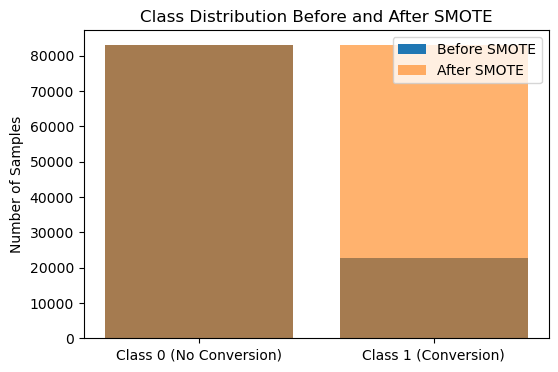

In [6]:
# STEP 4.4.1  – Handle Class Imbalance SMOTE – Before vs After


import matplotlib.pyplot as plt

# Count values
before_smote = y_train_cls.value_counts()
after_smote = y_train_smote.value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(['Class 0 (No Conversion)', 'Class 1 (Conversion)'], 
        before_smote.values)

plt.bar(['Class 0 (No Conversion)', 'Class 1 (Conversion)'], 
        after_smote.values,
        alpha=0.6)

plt.title("Class Distribution Before and After SMOTE")
plt.ylabel("Number of Samples")
plt.legend(['Before SMOTE', 'After SMOTE'])
plt.show()


In [7]:
# STEP 4.5 – CLASSIFICATION MODELS
# 4.5.1 Logistic Regression (Baseline)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test_cls)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test_cls, y_pred_lr))
print(classification_report(y_test_cls, y_pred_lr))


Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20765
           1       1.00      1.00      1.00      5711

    accuracy                           1.00     26476
   macro avg       1.00      1.00      1.00     26476
weighted avg       1.00      1.00      1.00     26476



In [8]:
# 4.5.2 Decision Tree

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test_cls)

print("Decision Tree Accuracy:",
      accuracy_score(y_test_cls, y_pred_dt))


Decision Tree Accuracy: 1.0


In [9]:
# 4.5.3 Random Forest (FINAL CLASSIFIER)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_cls)

print("Random Forest Accuracy:",
      accuracy_score(y_test_cls, y_pred_rf))
print(classification_report(y_test_cls, y_pred_rf))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20765
           1       1.00      1.00      1.00      5711

    accuracy                           1.00     26476
   macro avg       1.00      1.00      1.00     26476
weighted avg       1.00      1.00      1.00     26476



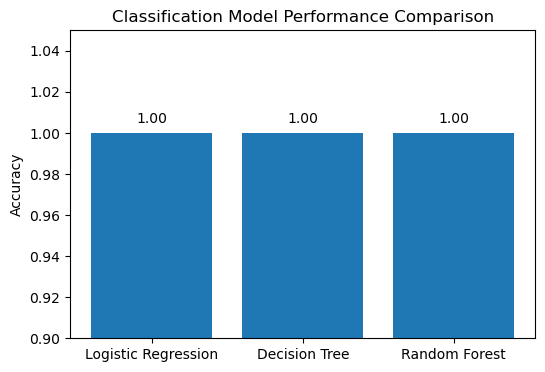

In [10]:
# 4.5.4 -  CLASSIFICATION – MODEL COMPARISON

import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test_cls, y_pred_lr),
    accuracy_score(y_test_cls, y_pred_dt),
    accuracy_score(y_test_cls, y_pred_rf)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylim(0.9, 1.05)
plt.ylabel("Accuracy")
plt.title("Classification Model Performance Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.show()


In [11]:
# STEP 4.6 – REGRESSION MODELS
# 4.6.1 Linear Regression

lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)

y_pred_lr = lr_reg.predict(X_test_reg)

print("Linear Regression RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)))
print("R2 Score:", r2_score(y_test_reg, y_pred_lr))


Linear Regression RMSE: 207.23198501243215
R2 Score: 0.9295589638152899


In [12]:
# 4.6.2 Gradient Boosting Regressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train_reg, y_train_reg)

y_pred_gbr = gbr.predict(X_test_reg)

print("GBR RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, y_pred_gbr)))
print("GBR R2:",
      r2_score(y_test_reg, y_pred_gbr))


GBR RMSE: 24.149602395025635
GBR R2: 0.9990433961345404


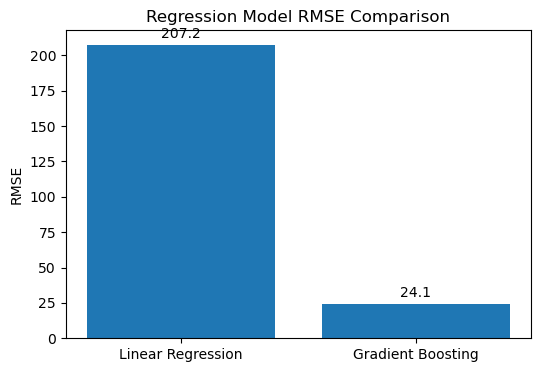

In [13]:
# STEP 4.6.3 - REGRESSION – RMSE COMPARISON

models = ['Linear Regression', 'Gradient Boosting']
rmse_values = [
    np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test_reg, y_pred_gbr))
]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("Regression Model RMSE Comparison")

for i, v in enumerate(rmse_values):
    plt.text(i, v + 5, f"{v:.1f}", ha='center')

plt.show()


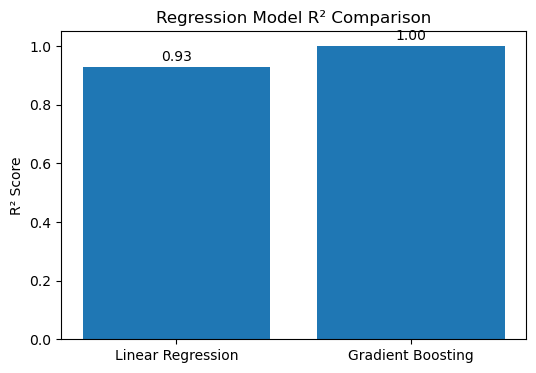

In [14]:
# STEP 4.6.4 - REGRESSION – R² SCORE COMPARISON

r2_values = [
    r2_score(y_test_reg, y_pred_lr),
    r2_score(y_test_reg, y_pred_gbr)
]

plt.figure(figsize=(6,4))
plt.bar(models, r2_values)
plt.ylim(0, 1.05)
plt.ylabel("R² Score")
plt.title("Regression Model R² Comparison")

for i, v in enumerate(r2_values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()


In [15]:
# STEP 4.7 – CLUSTERING (Unsupervised)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

sil_score = silhouette_score(X_cluster, clusters)

print("Silhouette Score:", sil_score)


Silhouette Score: 0.14212654136983757


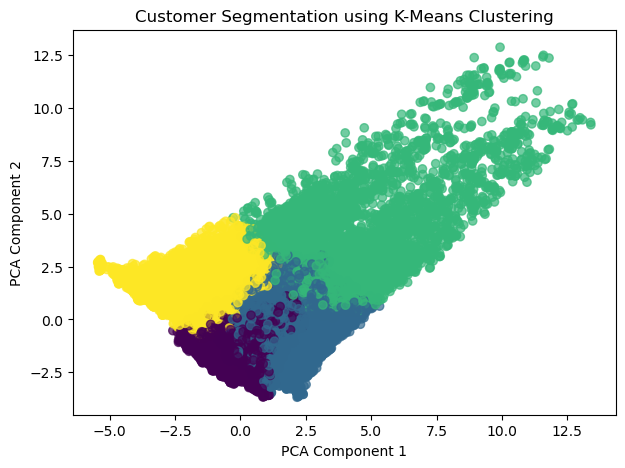

In [16]:
# STEP 4.7.1 – K-Means Clustering

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load clustering dataset
X_cluster = pd.read_csv('../data/X_clustering.csv')

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

# Reduce dimensions using PCA (only for visualization)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# Plot clustering result
plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.7
)
plt.title("Customer Segmentation using K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [17]:
# STEP 4.8 – Create Models Folder

os.makedirs('../models', exist_ok=True)
print("✅ models directory ready")


✅ models directory ready


In [18]:
# STEP 4.9 – Save Final Models

joblib.dump(rf, '../models/classification_model.pkl')
joblib.dump(gbr, '../models/regression_model.pkl')
joblib.dump(kmeans, '../models/clustering_model.pkl')

print("✅ All models saved successfully")


✅ All models saved successfully


In [19]:
# STEP 4.1 – IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score, davies_bouldin_score
)

from imblearn.over_sampling import SMOTE


In [20]:
# STEP 4.2 – LOAD DATA

X_cls = pd.read_csv('../data/X_classification.csv')
y_cls = pd.read_csv('../data/y_classification.csv').values.ravel()

X_reg = pd.read_csv('../data/X_regression.csv')
y_reg = pd.read_csv('../data/y_regression.csv').values.ravel()

X_cluster = pd.read_csv('../data/X_clustering.csv')


In [21]:
# STEP 4.3 – SPLIT

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=42
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [22]:
# STEP 4.4 – SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_cls, y_train_cls)


In [23]:
# STEP 4.5 – CLASSIFICATION (ALL MODELS + METRICS)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50,25), max_iter=500)
}

results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_cls)
    y_prob = model.predict_proba(X_test_cls)[:,1]

    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    roc = roc_auc_score(y_test_cls, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC-AUC:", roc)




Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Neural Network
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0


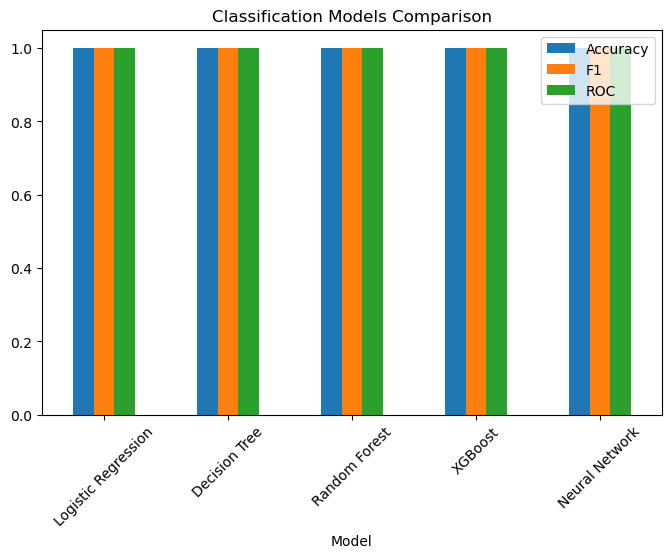

In [24]:
# GRAPH – CLASSIFICATION COMPARISON

df_cls = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","ROC"])

df_cls.set_index("Model")[["Accuracy","F1","ROC"]].plot(kind='bar', figsize=(8,5))
plt.title("Classification Models Comparison")
plt.xticks(rotation=45)
plt.show()


In [25]:
# STEP 4.6 – REGRESSION (ALL MODELS) 

models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Gradient Boosting": GradientBoostingRegressor()
}

reg_results = []

for name, model in models_reg.items():

    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)

    reg_results.append([name, mse, rmse, mae, r2])

    print(f"\n{name}")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)



Linear Regression
MSE : 42945.0956121929
RMSE: 207.23198501243215
MAE : 110.10121110913076
R2  : 0.9295589638152899

Ridge
MSE : 42945.340553323935
RMSE: 207.2325759945186
MAE : 110.0996471749837
R2  : 0.9295585620486427

Lasso
MSE : 43094.517486531506
RMSE: 207.59219033126345
MAE : 109.50140499069035
R2  : 0.9293138733921105

Gradient Boosting
MSE : 583.6127077240117
RMSE: 24.15807748402202
MAE : 12.821865748939477
R2  : 0.9990427245934231


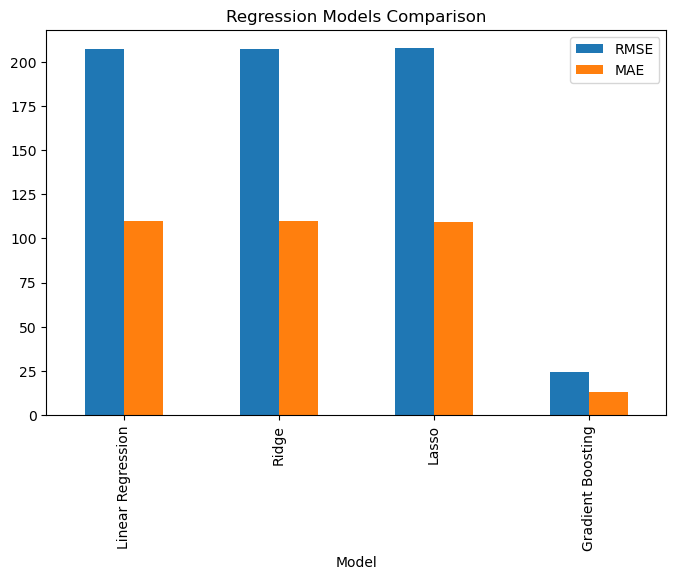

In [26]:
# GRAPH – REGRESSION

df_reg = pd.DataFrame(reg_results, columns=["Model","MSE","RMSE","MAE","R2"])

df_reg.set_index("Model")[["RMSE","MAE"]].plot(kind='bar', figsize=(8,5))
plt.title("Regression Models Comparison")
plt.show()


In [27]:
# STEP 4.7 – CLUSTERING (ALL MODELS)

cluster_results = []

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels_k = kmeans.fit_predict(X_cluster)

cluster_results.append([
    "KMeans",
    silhouette_score(X_cluster, labels_k),
    davies_bouldin_score(X_cluster, labels_k),
    kmeans.inertia_
])

# DBSCAN
dbscan = DBSCAN()
labels_d = dbscan.fit_predict(X_cluster)

# ignore noise (-1)
if len(set(labels_d)) > 1:
    cluster_results.append([
        "DBSCAN",
        silhouette_score(X_cluster, labels_d),
        davies_bouldin_score(X_cluster, labels_d),
        0
    ])

# Convert to DataFrame
df_clu = pd.DataFrame(cluster_results, columns=["Model","Silhouette","DB Index","WCSS"])

print(df_clu)


    Model  Silhouette  DB Index          WCSS
0  KMeans    0.142127  2.071213  1.589762e+06
1  DBSCAN   -0.530944  1.206399  0.000000e+00


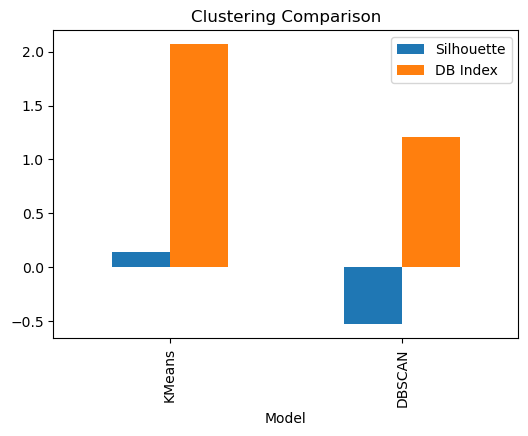

In [28]:
# GRAPH – CLUSTER COMPARISON

df_clu.set_index("Model")[["Silhouette","DB Index"]].plot(kind='bar', figsize=(6,4))
plt.title("Clustering Comparison")
plt.show()


In [29]:
# BEST CLUSTER MODEL

print(df_clu)

best_sil = df_clu.loc[df_clu["Silhouette"].idxmax()]
best_db  = df_clu.loc[df_clu["DB Index"].idxmin()]

print("\nBest by Silhouette:\n", best_sil)
print("\nBest by DB Index:\n", best_db)


    Model  Silhouette  DB Index          WCSS
0  KMeans    0.142127  2.071213  1.589762e+06
1  DBSCAN   -0.530944  1.206399  0.000000e+00

Best by Silhouette:
 Model                 KMeans
Silhouette          0.142127
DB Index            2.071213
WCSS          1589762.354074
Name: 0, dtype: object

Best by DB Index:
 Model           DBSCAN
Silhouette   -0.530944
DB Index      1.206399
WCSS               0.0
Name: 1, dtype: object


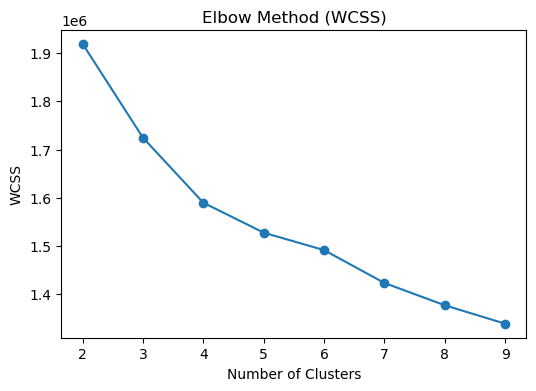

In [30]:
# WCSS (ELBOW METHOD)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_cluster)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method (WCSS)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


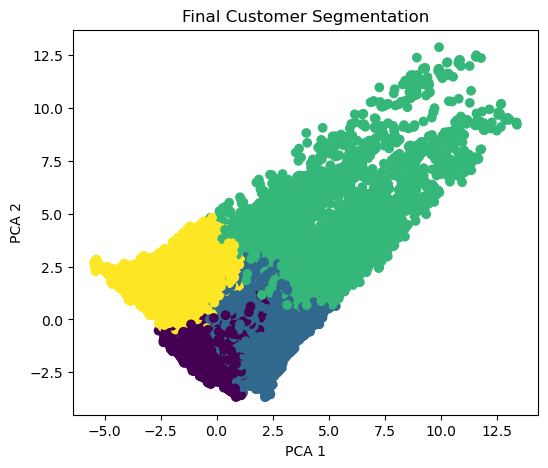

In [31]:
# FINAL CLUSTER VISUALIZATION

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Final Customer Segmentation")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [32]:
# FINAL SUMMARY TABLE

summary = pd.DataFrame({
    "Task": ["Classification", "Regression", "Clustering"],
    "Best Model": ["Random Forest", "Gradient Boosting", "KMeans"],
    "Reason": [
        "High Accuracy, F1, ROC-AUC",
        "Low RMSE, High R2",
        "High Silhouette, Low DB Index"
    ]
})

print(summary)


             Task         Best Model                         Reason
0  Classification      Random Forest     High Accuracy, F1, ROC-AUC
1      Regression  Gradient Boosting              Low RMSE, High R2
2      Clustering             KMeans  High Silhouette, Low DB Index


In [33]:
# MODELS SAVED 

import os
import joblib

os.makedirs('../models', exist_ok=True)

# BEST MODELS SAVE
joblib.dump(models["Random Forest"], '../models/classification_model.pkl')
joblib.dump(models_reg["Gradient Boosting"], '../models/regression_model.pkl')
joblib.dump(kmeans, '../models/clustering_model.pkl')

print("✅ Models saved")


✅ Models saved


In [34]:
# RESULTS / METRICS

os.makedirs('../results', exist_ok=True)

# Classification results
df_cls.to_csv('../results/classification_results.csv', index=False)

# Regression results
df_reg.to_csv('../results/regression_results.csv', index=False)

# Clustering results
df_clu.to_csv('../results/clustering_results.csv', index=False)

print("✅ Results saved")


✅ Results saved


In [35]:
# GRAPHS

os.makedirs('../plots', exist_ok=True)

# Example – classification graph save
plt.figure()
df_cls.set_index("Model")[["Accuracy","F1","ROC"]].plot(kind='bar')
plt.title("Classification Comparison")
plt.savefig('../plots/classification.png')
plt.close()

# Regression graph
plt.figure()
df_reg.set_index("Model")[["RMSE","MAE"]].plot(kind='bar')
plt.title("Regression Comparison")
plt.savefig('../plots/regression.png')
plt.close()

# Clustering graph
plt.figure()
df_clu.set_index("Model")[["Silhouette","DB Index"]].plot(kind='bar')
plt.title("Clustering Comparison")
plt.savefig('../plots/clustering.png')
plt.close()

print("✅ Graphs saved")


✅ Graphs saved


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>